## Training Dynamics
The training dynamics in the MLP and LSTM are very similar. By epoch 15-20 there is a gap between training and validation performance in both models. This is especially visible in the loss curves. This gap, where the performance on the training set is much higher than the performance on the validation set, is a clear sign of overfitting. Still, the gap here is much smaller than it used to be before I added dropout to both models. Other architectural changes to address overfitting could include gradient clipping in the LSTM, or reducing the complexity of either model by removing layers and reducing the hidden layer size. One training change to address this is early stopping, but for this assignment we were required to train for at least 30 epochs.  

The overfitting in the MLP and LSTM is nowhere near as bad as it is in the BERT, GRU, and RNN models. Each of these ends training with higher validation loss than at initialization. 

::: {layout-ncol=2}
![MLP Learning Curves](outputs/mlp_f1_learning_curves.png)

![LSTM Learning Curves](outputs/lstm_f1_learning_curves.png)
:::

## Model Performance and Error Analysis
The MLP had a final test Macro F1 score of 0.71 and the LSTM has a final test Macro F1 score of 0.72, but the LSTM has a slightly larger gap between test Macro F1 and training Macro F1. So, although the LSTM performed better it generalized worse. However, there is randomness in the training so without looking at multiple different training loops for both the LSTM and MLP it is impossible to make a definite conclusion. 

The sentiment that is hardest to classify for the models is positive, followed by neutral. Looking at the confusion matrix for the MLP we see that the primary issue is the model mixing up positive and negative text. I think generally, even for humans, it can be difficult to figure out if text has a positive or neutral sentiment. Negative sentiment is, on the other hand, generally very easy for humans to pick up on. So the model performance may just be a downstream effect of the ability of the humans who labeled the data.

Model Performance Results:
  model  macro_f1  f1_negative  f1_neutral  f1_positive
0   MLP  0.710224     0.696078    0.790816     0.643777
1  LSTM  0.722740     0.707965    0.801489     0.658768
2   RNN  0.691352     0.670103    0.813953     0.590000
3   GRU  0.732444     0.712871    0.828375     0.656085
4  BERT  0.793192     0.794258    0.847001     0.738318
5   GPT  0.803430     0.813559    0.853081     0.743649


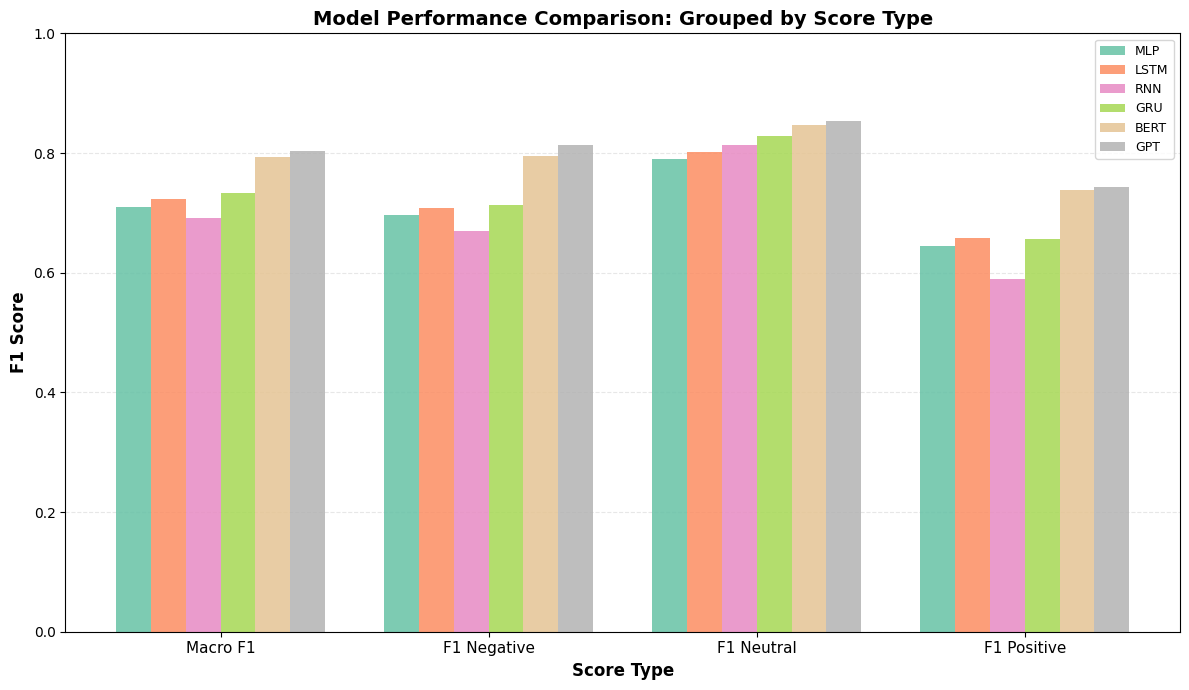

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results_df = pd.read_csv('outputs/model_performance.csv')
print("Model Performance Results:")
print(results_df)

metrics = ['macro_f1', 'f1_negative', 'f1_neutral', 'f1_positive']
metric_labels = ['Macro F1', 'F1 Negative', 'F1 Neutral', 'F1 Positive']
models = results_df['model'].values

x = np.arange(len(metric_labels))
width = 0.13
fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.Set2(np.linspace(0, 1, len(models)))
for i, model in enumerate(models):
    offset = (i - len(models) / 2 + 0.5) * width
    values = [results_df.loc[results_df['model'] == model, m].values[0] for m in metrics]
    ax.bar(x + offset, values, width, label=model, color=colors[i], alpha=0.85)

ax.set_xlabel('Score Type', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison: Grouped by Score Type', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim([0, 1.0])
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('outputs/model_comparison_f1_scores.png', dpi=300, bbox_inches='tight')
plt.show()

![MLP Confusion Matrix](outputs/mlp_confusion_matrix.png)

## Cross Model Comparison
Mean-pooling means we lose all information about the words in the sentence: "the dog walked the person" and "the person walked the dog" have different meanings but would get the same embedding. This, of course, limits the ability of the MLP to classify the sentences. The LSTM results in a sentence embedding that takes word order into account which can improve performance where word order is importance. BERT/GPT did outperform the classical baselines. The not only have more meaningful embeddings of the individual words because of the extensive pretraining, but they also are able to better represent the context of the words. 

The RNN performed the worst, possibly because of vanishing gradients or other issues during training. It is possible that with additional hyperparameter tuning the RNN performance could be improved. The MLP outperformed the RNN, despite not having any knowledge of word order. The LSTM out performed the MLP likely thanks to its use of word order. The GRU performed slightly better than the LSTM, I am not sure exactly why but based on quick research it could be due to fewer parameters and better generalizablity. GPT and BERT performed best, thanks to their better encodings, representation of context, and tuning.  

## AI Use Disclosure (Required)

If you used any AI-enabled tools (e.g., ChatGPT, GitHub Copilot, Claude, or other LLM assistants) while working on this assignment, you must disclose that use here. The goal is transparency-not punishment.

In your disclosure, briefly include:
- **Tool(s) used:** (name + version if known)
- **How you used them:** (e.g., concept explanation, debugging, drafting code, rewriting text)
- **What you verified yourself:** (e.g., reran the notebook, checked outputs/plots, checked shapes, read documentation)
- **What you did *not* use AI for (if applicable):** (optional)

You are responsible for the correctness of your submission, even if AI suggested code or explanations.

#### <font color="red">Write your disclosure here.</font>


Gemini Pro, Cursor Auto
Used for debugging and finding issues with training loops; Improving plotting code. 
Did lots of quick testing and comparing code to the provided training loops.